# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

## 1. Análise do CSV — classificação

Vamos trabalhar somente com as três entradas permitidas pela atividade:

- `potencia_kw`: potência outorgada do empreendimento, em kW.
- `latitude`: latitude aproximada do empreendimento.
- `longitude`: longitude aproximada do empreendimento.

O alvo `y` é `fonte`, com três classes: `Solar`, `Eólica` e `Hidráulica`. `SigTipoGeracao`, nome do empreendimento, CEG e descrições da fonte já foram transformados/omitidos na etapa de geração do CSV e não serão usados como entradas.

In [9]:
# Carregamento do CSV da tarefa de classificação
dados_classificacao = pd.read_csv("aneel_classificacao_orange.csv")

print("Dimensões:", dados_classificacao.shape)
print("\nTipos das colunas:")
print(dados_classificacao.dtypes)

print("\nValores ausentes por coluna:")
display(dados_classificacao.isna().sum().to_frame("ausentes"))

print("\nContagem por classe:")
display(dados_classificacao["fonte"].value_counts().rename_axis("fonte").to_frame("quantidade"))

print("\nResumo estatístico:")
display(dados_classificacao.describe())

X_classificacao = dados_classificacao[["potencia_kw", "latitude", "longitude"]]
y_classificacao = dados_classificacao["fonte"]

print("\nX:", X_classificacao.shape, "-> potencia_kw, latitude, longitude")
print("y:", y_classificacao.shape, "-> fonte")

Dimensões: (3876, 4)

Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes por coluna:


,ausentes
potencia_kw,0
latitude,0
longitude,0
fonte,0



Contagem por classe:


,quantidade
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200



Resumo estatístico:


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.173571e+04,-12.682268,-46.271236
std,3.016509e+05,9.517716,8.249075
min,1.600000e-01,-33.722806,-69.941389
25%,4.000000e+02,-21.187129,-52.585932
50%,1.200000e+04,-10.469532,-47.645768
75%,3.000000e+04,-4.085391,-41.324957
max,1.123310e+07,3.831392,0.000000



X: (3876, 3) -> potencia_kw, latitude, longitude
y: (3876,) -> fonte


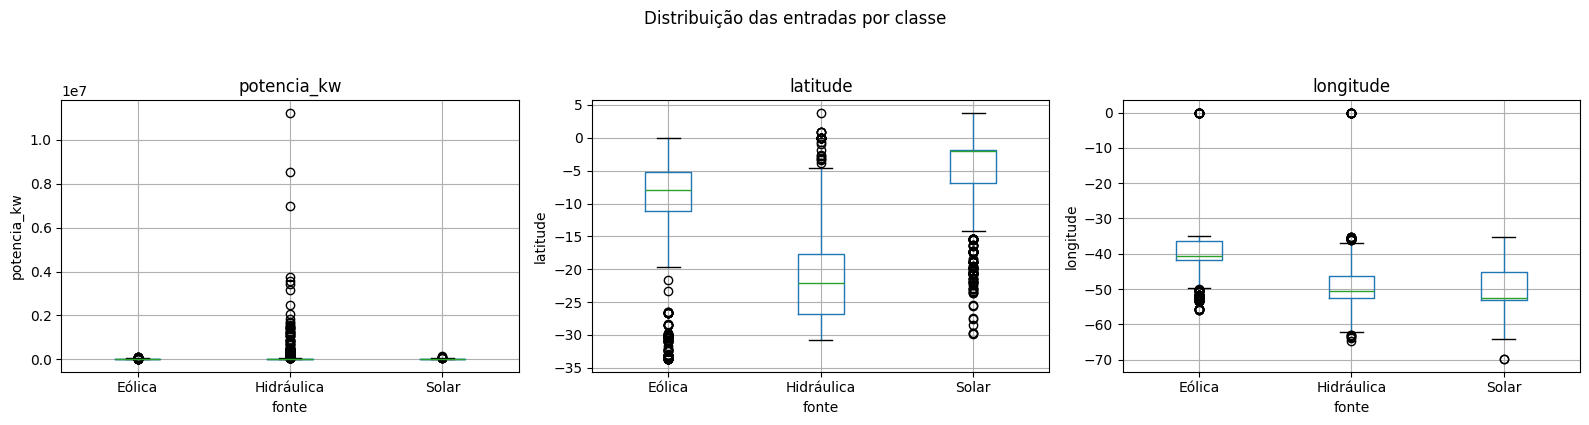

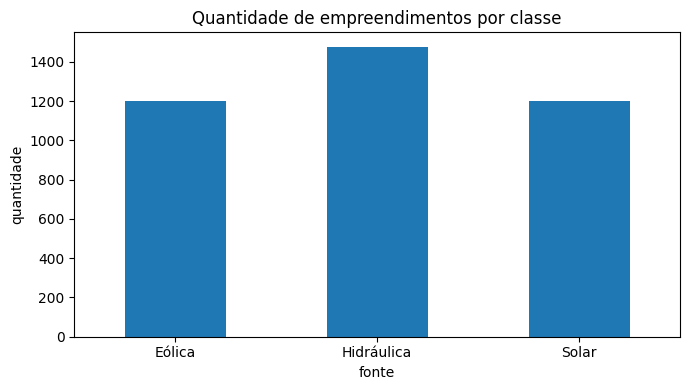

In [10]:
# Distribuições relevantes: distribuição das classes e boxplots das três entradas por classe
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, coluna in zip(axes, ["potencia_kw", "latitude", "longitude"]):
    dados_classificacao.boxplot(column=coluna, by="fonte", ax=ax)
    ax.set_title(coluna)
    ax.set_xlabel("fonte")
    ax.set_ylabel(coluna)
plt.suptitle("Distribuição das entradas por classe", y=1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
dados_classificacao["fonte"].value_counts().sort_index().plot(kind="bar")
plt.title("Quantidade de empreendimentos por classe")
plt.xlabel("fonte")
plt.ylabel("quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Divisão e treino — classificação

A divisão será **estratificada**, com 80% para treino e 20% para teste e `random_state=42`. Para evitar vazamento de dados, o `StandardScaler` é usado dentro de `Pipeline`: assim, os parâmetros de escala são aprendidos somente no conjunto de treino.

Os três classificadores escolhidos são:

1. **KNN** — usa a proximidade entre empreendimentos; como a distância depende da escala, será padronizado.
2. **Regressão Logística** — serve como referência de classificação com fronteiras lineares e é simples de interpretar; também será padronizada.
3. **Random Forest** — combina várias árvores e consegue representar relações não lineares entre potência e localização. Não necessita de padronização.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_treino_clf, X_teste_clf, y_treino_clf, y_teste_clf = train_test_split(
    X_classificacao,
    y_classificacao,
    test_size=0.20,
    random_state=42,
    stratify=y_classificacao
)

modelos_classificacao = {
    "KNN": Pipeline([
        ("escala", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=7))
    ]),
    "Regressão Logística": Pipeline([
        ("escala", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    )
}

predicoes_classificacao = {}
resultados_classificacao = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino_clf, y_treino_clf)
    y_pred = modelo.predict(X_teste_clf)
    predicoes_classificacao[nome] = y_pred

    resultados_classificacao.append({
        "Algoritmo": nome,
        "Accuracy": accuracy_score(y_teste_clf, y_pred),
        "Precision_macro": precision_score(y_teste_clf, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_teste_clf, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_teste_clf, y_pred, average="macro", zero_division=0)
    })

tabela_classificacao = (
    pd.DataFrame(resultados_classificacao)
      .sort_values(["F1_macro", "Accuracy"], ascending=False)
      .reset_index(drop=True)
)

print("Métricas Precision, Recall e F1 calculadas com média MACRO (média simples entre as três classes).")
display(tabela_classificacao.style.format({
    "Accuracy": "{:.4f}",
    "Precision_macro": "{:.4f}",
    "Recall_macro": "{:.4f}",
    "F1_macro": "{:.4f}"
}))

Métricas Precision, Recall e F1 calculadas com média MACRO (média simples entre as três classes).


,Algoritmo,Accuracy,Precision_macro,Recall_macro,F1_macro
0,Random Forest,0.9729,0.9742,0.9714,0.9724
1,KNN,0.9652,0.9667,0.9636,0.9649
2,Regressão Logística,0.8235,0.8275,0.8200,0.8182


## 3. Avaliação — classificação

A matriz de confusão mostra, para cada modelo, as classes verdadeiras nas linhas e as classes previstas nas colunas. A diagonal representa acertos; os valores fora da diagonal representam confusões entre classes.

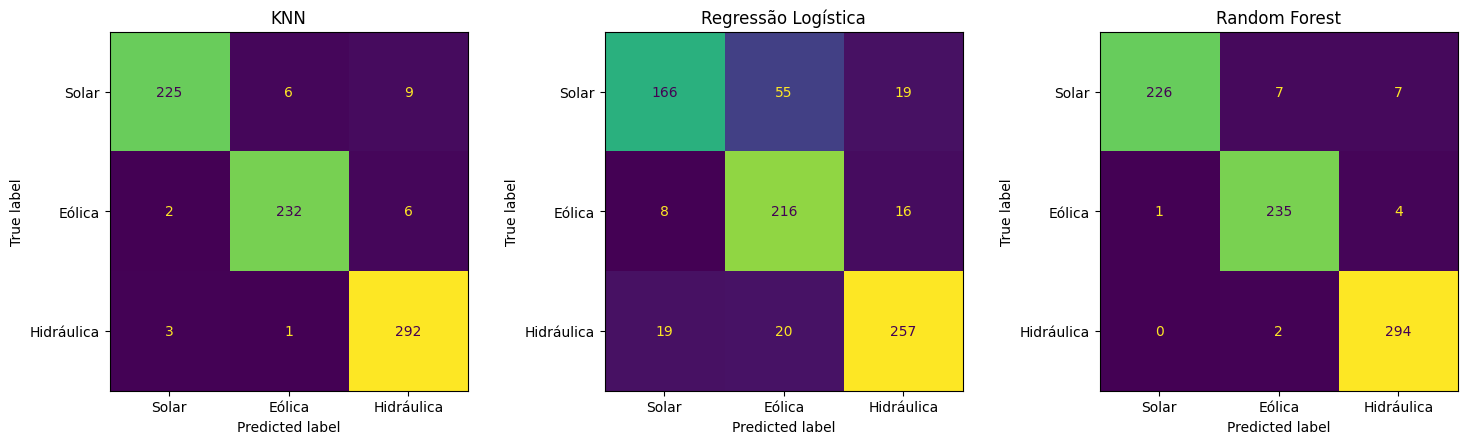

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

classes_classificacao = ["Solar", "Eólica", "Hidráulica"]
matrizes_classificacao = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nome, y_pred) in zip(axes, predicoes_classificacao.items()):
    cm = confusion_matrix(y_teste_clf, y_pred, labels=classes_classificacao)
    matrizes_classificacao[nome] = cm

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_classificacao)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(nome)

plt.tight_layout()
plt.show()

## 4. Interpretação — classificação

Para esta atividade, a escolha é feita olhando principalmente o **F1 macro**, porque ele dá o mesmo peso às três classes mesmo quando a quantidade de exemplos é diferente. Accuracy, Precision e Recall completam a análise.

A potência e a localização podem ajudar, mas não são suficientes para uma aplicação real. Empreendimentos de fontes diferentes podem compartilhar faixas semelhantes de potência e ocupar regiões geográficas próximas. Além disso, a classificação real depende de informações de projeto, tecnologia, regras/registros do empreendimento e outras características que não estão representadas nas três entradas permitidas.

O bloco abaixo identifica automaticamente o modelo com maior F1 macro nesta divisão e a principal confusão fora da diagonal da respectiva matriz.

In [13]:
melhor_modelo_clf = tabela_classificacao.iloc[0]["Algoritmo"]
cm_melhor = matrizes_classificacao[melhor_modelo_clf].copy()

np.fill_diagonal(cm_melhor, 0)
i, j = np.unravel_index(np.argmax(cm_melhor), cm_melhor.shape)

print(f"Modelo selecionado para esta divisão: {melhor_modelo_clf}")
print(
    f"Maior confusão fora da diagonal: verdadeiro = {classes_classificacao[i]}, "
    f"previsto = {classes_classificacao[j]}, quantidade = {cm_melhor[i, j]}"
)
print(
    "Interpretação: a matriz de confusão deve ser lida junto das métricas macro; "
    "uma confusão alta entre duas classes indica que potência e localização não "
    "separam completamente esses tipos de empreendimento."
)

Modelo selecionado para esta divisão: Random Forest
Maior confusão fora da diagonal: verdadeiro = Solar, previsto = Eólica, quantidade = 7
Interpretação: a matriz de confusão deve ser lida junto das métricas macro; uma confusão alta entre duas classes indica que potência e localização não separam completamente esses tipos de empreendimento.


# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [14]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [15]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [16]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [17]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## 1. Análise do CSV — regressão

As cinco entradas (`X`) usadas nesta tarefa são:

- `temperatura_c`: temperatura do ar a 2 m (°C).
- `umidade_pct`: umidade relativa a 2 m (%).
- `nuvens_pct`: cobertura de nuvens (%).
- `vento_kmh`: velocidade do vento a 10 m (km/h).
- `hora`: hora local do registro, de 7 a 17.

O alvo `y` é `radiacao_w_m2`, isto é, a radiação solar horizontal média da hora em W/m². `data_hora` serve para ordenar os registros e separar treino/teste, mas não entra em `X`.

In [18]:
# Carregamento e organização temporal do CSV de regressão
dados_regressao = pd.read_csv("meteo_regressao_orange.csv")

dados_regressao["data_hora"] = pd.to_datetime(dados_regressao["data_hora"])
dados_regressao = dados_regressao.sort_values("data_hora").reset_index(drop=True)

print("Dimensões:", dados_regressao.shape)
print("\nTipos das colunas:")
print(dados_regressao.dtypes)

print("\nValores ausentes por coluna:")
display(dados_regressao.isna().sum().to_frame("ausentes"))

print("\nResumo estatístico:")
display(dados_regressao.describe())

X_regressao = dados_regressao[
    ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
]
y_regressao = dados_regressao["radiacao_w_m2"]

print("\nX:", X_regressao.shape, "-> temperatura_c, umidade_pct, nuvens_pct, vento_kmh, hora")
print("y:", y_regressao.shape, "-> radiacao_w_m2")

Dimensões: (1001, 7)

Tipos das colunas:
data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object

Valores ausentes por coluna:


,ausentes
data_hora,0
temperatura_c,0
umidade_pct,0
nuvens_pct,0
vento_kmh,0
hora,0
radiacao_w_m2,0



Resumo estatístico:


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950



X: (1001, 5) -> temperatura_c, umidade_pct, nuvens_pct, vento_kmh, hora
y: (1001,) -> radiacao_w_m2


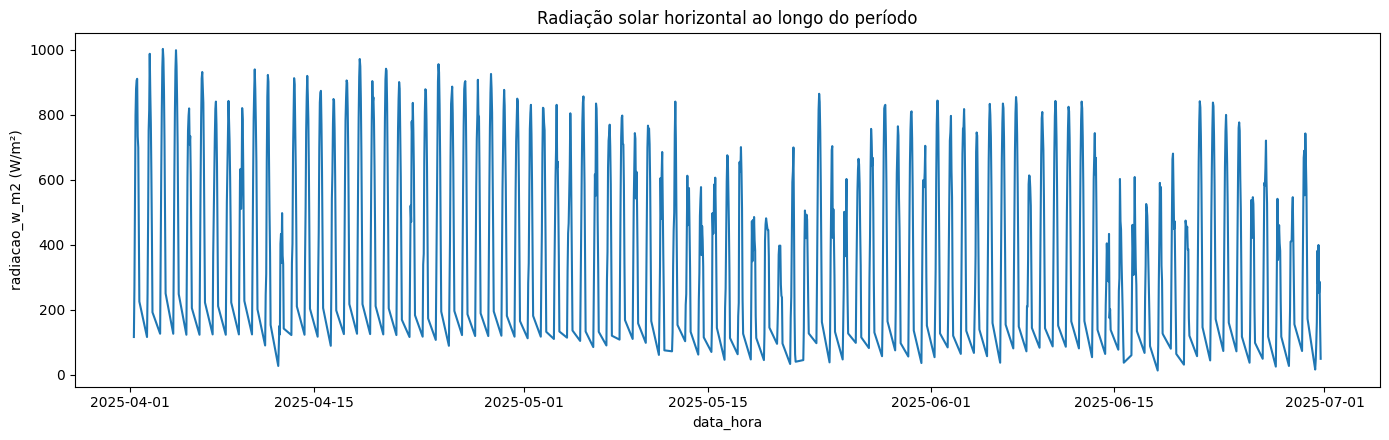

In [19]:
# Visualização da variável-alvo ao longo do tempo
plt.figure(figsize=(14, 4.5))
plt.plot(dados_regressao["data_hora"], dados_regressao["radiacao_w_m2"])
plt.title("Radiação solar horizontal ao longo do período")
plt.xlabel("data_hora")
plt.ylabel("radiacao_w_m2 (W/m²)")
plt.tight_layout()
plt.show()

## 2. Divisão temporal e treino — regressão

Os dados permanecem em ordem cronológica. Os primeiros 80% dos registros são usados para treino e os últimos 20% para teste, sem embaralhamento.

Não usamos `radiacao_w_m2` como entrada do próprio registro. Para demonstrar o cuidado com transformações aprendidas dos dados, a Regressão Linear usa `StandardScaler` dentro de um `Pipeline`, ajustado apenas no treino. Os dois modelos baseados em árvores não precisam de escala.

In [20]:
# Separação temporal: primeiros ~80% para treino e últimos ~20% para teste
corte_regressao = int(len(dados_regressao) * 0.80)

X_treino_reg = X_regressao.iloc[:corte_regressao]
X_teste_reg = X_regressao.iloc[corte_regressao:]
y_treino_reg = y_regressao.iloc[:corte_regressao]
y_teste_reg = y_regressao.iloc[corte_regressao:]

print("Registros de treino:", len(X_treino_reg))
print("Registros de teste:", len(X_teste_reg))
print("Última hora do treino:", dados_regressao.loc[corte_regressao - 1, "data_hora"])
print("Primeira hora do teste:", dados_regressao.loc[corte_regressao, "data_hora"])

modelos_regressao = {
    "Regressão Linear": Pipeline([
        ("escala", StandardScaler()),
        ("modelo", LinearRegression())
    ]),
    "Árvore de Decisão": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=4,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

predicoes_regressao = {}
resultados_regressao = []

for nome, modelo in modelos_regressao.items():
    modelo.fit(X_treino_reg, y_treino_reg)
    y_pred = modelo.predict(X_teste_reg)
    predicoes_regressao[nome] = y_pred

    resultados_regressao.append({
        "Algoritmo": nome,
        "MAE (W/m²)": mean_absolute_error(y_teste_reg, y_pred),
        "MSE ((W/m²)²)": mean_squared_error(y_teste_reg, y_pred),
        "R2": r2_score(y_teste_reg, y_pred)
    })

tabela_regressao = (
    pd.DataFrame(resultados_regressao)
      .sort_values(["MAE (W/m²)", "R2"], ascending=[True, False])
      .reset_index(drop=True)
)

display(tabela_regressao.style.format({
    "MAE (W/m²)": "{:.2f}",
    "MSE ((W/m²)²)": "{:.2f}",
    "R2": "{:.4f}"
}))

Registros de treino: 800
Registros de teste: 201
Última hora do treino: 2025-06-12 14:00:00
Primeira hora do teste: 2025-06-12 15:00:00


,Algoritmo,MAE (W/m²),MSE ((W/m²)²),R2
0,Random Forest,67.19,7419.60,0.8419
1,Árvore de Decisão,82.39,12361.86,0.7365
2,Regressão Linear,145.20,30034.20,0.3598


## 3. Avaliação — regressão

- **MAE**: erro absoluto médio, na mesma unidade da radiação (W/m²).
- **MSE**: erro quadrático médio, em (W/m²)²; erros grandes têm peso maior.
- **R²**: mede quanto da variação observada no conjunto de teste é explicada pelo modelo; valores mais próximos de 1 indicam maior capacidade explicativa na divisão utilizada.

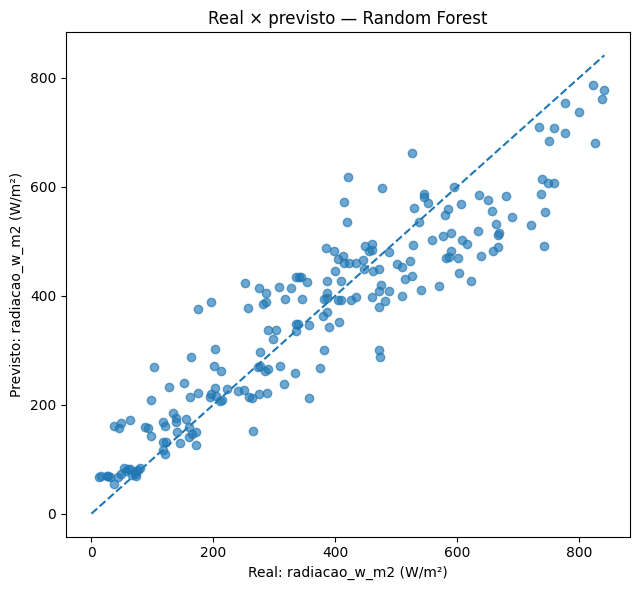

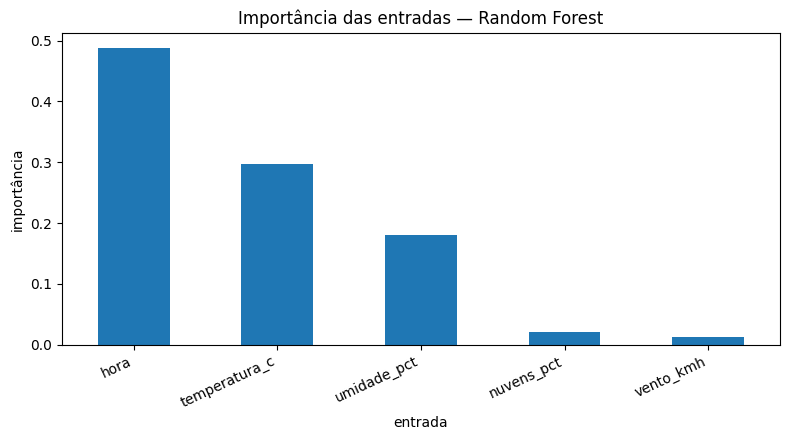

,importancia
hora,0.488505
temperatura_c,0.296416
umidade_pct,0.181247
nuvens_pct,0.020322
vento_kmh,0.013511


In [21]:
# Gráfico de valores reais x previstos para o modelo com menor MAE
modelo_plot_reg = tabela_regressao.iloc[0]["Algoritmo"]
y_pred_plot_reg = predicoes_regressao[modelo_plot_reg]

plt.figure(figsize=(6.5, 6))
plt.scatter(y_teste_reg, y_pred_plot_reg, alpha=0.65)
limite_max = max(float(y_teste_reg.max()), float(np.max(y_pred_plot_reg)))
plt.plot([0, limite_max], [0, limite_max], linestyle="--")
plt.title(f"Real × previsto — {modelo_plot_reg}")
plt.xlabel("Real: radiacao_w_m2 (W/m²)")
plt.ylabel("Previsto: radiacao_w_m2 (W/m²)")
plt.tight_layout()
plt.show()

# Peso relativo das cinco entradas segundo o Random Forest
rf_reg = modelos_regressao["Random Forest"]
importancias_hora = pd.Series(
    rf_reg.feature_importances_,
    index=X_regressao.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 4.5))
importancias_hora.plot(kind="bar")
plt.title("Importância das entradas — Random Forest")
plt.xlabel("entrada")
plt.ylabel("importância")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(importancias_hora.rename("importancia").to_frame())

## 4. Interpretação — regressão

A hora pode ter peso importante porque a radiação solar possui um ciclo diário: o período do dia ajuda a localizar o registro dentro desse ciclo. Mesmo assim, a hora sozinha não descreve a nebulosidade, umidade, temperatura e vento.

A tabela deve ser interpretada em conjunto: MAE informa o erro típico em W/m², MSE destaca erros maiores e R² mostra a parcela da variabilidade explicada pelo modelo. A escolha do modelo nesta atividade pode ser feita pelo menor MAE, usando MSE e R² como apoio.

É importante separar **radiação** de **energia elétrica produzida**. `radiacao_w_m2` é uma irradiância instantânea/média da hora por unidade de área. A energia fotovoltaica depende da irradiância acumulada no tempo e também da área dos módulos, eficiência, temperatura dos módulos, orientação/inclinação, perdas elétricas, inversor e condições do sistema. Portanto, estimar a radiação não transforma automaticamente o resultado em kWh gerados.

In [22]:
melhor_modelo_reg = tabela_regressao.iloc[0]["Algoritmo"]

print(f"Modelo com menor MAE nesta divisão temporal: {melhor_modelo_reg}")
print(
    "O erro deve ser interpretado na unidade W/m² (MAE) e em (W/m²)² (MSE). "
    "O R² complementa a leitura ao indicar a variabilidade explicada no teste."
)

print("\nPeso das entradas no Random Forest:")
for nome, valor in importancias_hora.items():
    print(f"- {nome}: {valor:.4f}")

print(
    "\nNenhum valor de radiacao_w_m2 do próprio registro foi usado em X. "
    "A variável radiacao_w_m2 foi usada somente como alvo y."
)

Modelo com menor MAE nesta divisão temporal: Random Forest
O erro deve ser interpretado na unidade W/m² (MAE) e em (W/m²)² (MSE). O R² complementa a leitura ao indicar a variabilidade explicada no teste.

Peso das entradas no Random Forest:
- hora: 0.4885
- temperatura_c: 0.2964
- umidade_pct: 0.1812
- nuvens_pct: 0.0203
- vento_kmh: 0.0135

Nenhum valor de radiacao_w_m2 do próprio registro foi usado em X. A variável radiacao_w_m2 foi usada somente como alvo y.


# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)